# rathore2021 — Rathore et al. (2021) TopoAct

Mapper on a trained CNN's **activation vectors** (L2-norm lens) — the graph exposes concept clusters in activation space.


## What the paper does

**TopoAct** explores the *shape* of a layer's activation space with **Mapper**.  Each input's activation vector is a point; the lens is its **`L2` norm**; overlapping lens bins are clustered and linked into a Mapper graph whose nodes are activation clusters and edges are overlaps.

**Methodology:** activation vectors → `L2`-norm lens → Mapper graph (nodes = clusters, edges = overlap).

**Expected result:** the graph exposes interpretable **concept clusters** (at ImageNet scale, dogs/vehicles/… with branching subhierarchy).  At our small scale, Mapper nodes should still group inputs of the **same class** — colour the graph by label to see it.


## Dataset & model in the paper

- **arXiv:** [https://arxiv.org/abs/1912.06332](https://arxiv.org/abs/1912.06332)
- **Venue:** Computer Graphics Forum 2021 (EuroVis)
- **Datasets used:** ImageNet, CIFAR-10.
- **Models used:** InceptionV1 (GoogLeNet).  Here: a small CNN on CIFAR-10.
- **Headline result to aim for:** The Mapper graph of mixed4c activations reveals high-level concept clusters with branching topology matching the ImageNet subhierarchy.
- **Reference code:** [https://github.com/tdavislab/TopoAct](https://github.com/tdavislab/TopoAct)
- **Other notes:** Live demo: https://tdavislab.github.io/TopoAct/

To reproduce paper numbers, replace the synthetic-data cell below with the real model snapshot / activations / trajectory.  Everything else in the notebook stays the same.


**This notebook runs on real activations.**  A small CNN is trained on the local CIFAR-10 cache and its penultimate activations are Mapper-ed.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch
from tanc import TDAPipeline
from paper_reproduce._torch_setup import (
    load_mnist, load_fashion_mnist, load_cifar10, load_cifar100,
    SmallMLP, SmallCNN, CNN_FCN, CNN_FCN2, VGGLike, train_briefly, extract_snapshot, accuracy, pick_device,
)
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'


## 1. Train a CNN, take a layer's activation vectors


In [2]:
X_tr, y_tr = load_cifar10('train', n_samples=5000)
X_te, y_te = load_cifar10('test',  n_samples=500)
# A plain (no-BatchNorm) CNN: the L2-norm lens needs activation *magnitude*
# to vary across inputs, which BatchNorm would flatten away.
model = CNN_FCN(in_channels=3, num_classes=10, width=24, feat=96, hidden=48)
train_briefly(model, X_tr, y_tr, X_te, y_te, epochs=40,
              aspects=['activations'], device=DEVICE, verbose=False)
print('test accuracy:', accuracy(model, X_te, y_te, device=DEVICE))
n = 400; labels = y_te[:n]


paper_reproduce/_torch_setup.py:525: UserWarning: Model 'Sequential' has both fully-connected (linear / SoRO) and conv layers. Defaulting to the fully-connected layers. Pass layer_selection='all_linear', 'all_conv', 'soro', 'linear_and_conv', 'all', or a list of names/indices to suppress this warning.
  extractor = TrainingExtractor(


test accuracy: 0.34


## 2. Mapper of activation space, coloured by class — model-first

`fit_model` extracts the penultimate (`fc1`) layer's activations and runs Mapper — no manual extraction.  A coarser cover than the paper's `Mapper(70, 0.3)` keeps the small-scale graph readable.


Mapper graph: {'n_nodes': 20, 'n_edges': 16, 'mean_degree': 1.6, 'density': 0.08421052631578947, 'n_connected_components': 4, 'is_connected': False, 'mean_clustering_coefficient': 0.0, 'diameter': inf}


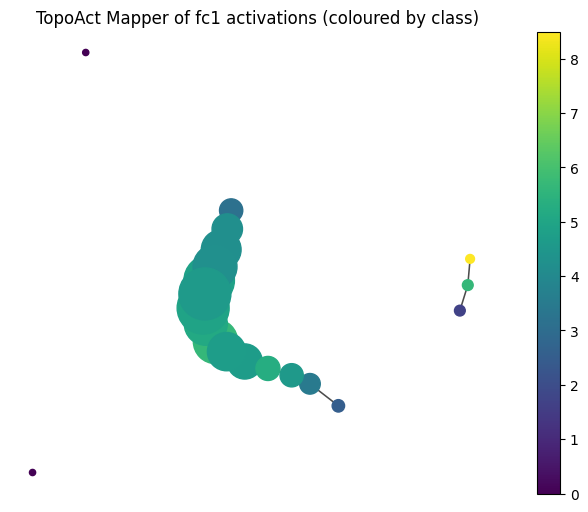

In [3]:
pipe = TDAPipeline.from_paper("rathore2021",
                            tool_kwargs__n_intervals=30,
                            tool_kwargs__overlap_frac=0.3)
result = pipe.fit_model(model, X_te[:n],
                        representation='fc1', layer_selection='all_linear')
fig = result.plot('graph', color_by=labels,
                  title='TopoAct Mapper of fc1 activations (coloured by class)')
print('Mapper graph:', result.mapper.stats)


## 3. Per-node exemplars — do nodes group one class?

`node_exemplars` returns the representative input indices per node; we look at their class labels to check each cluster is class-coherent.


In [4]:
from tanc.topo_tools import node_exemplars
members = result.mapper.node_members
for nid, idxs in list(members.items())[:8]:
    cls = labels[np.asarray(idxs)]
    vals, cnts = np.unique(cls, return_counts=True)
    purity = cnts.max() / cnts.sum()
    print(f'  node {nid:2d}: {len(idxs):3d} inputs, dominant class {vals[cnts.argmax()]} '
          f'(purity {purity:.2f})')


  node  0:   2 inputs, dominant class 8 (purity 0.50)
  node  1:  11 inputs, dominant class 0 (purity 0.18)
  node  2:  66 inputs, dominant class 5 (purity 0.20)
  node  3:  14 inputs, dominant class 0 (purity 0.29)
  node  4:   4 inputs, dominant class 1 (purity 0.50)
  node  5:  51 inputs, dominant class 8 (purity 0.18)
  node  6:  41 inputs, dominant class 5 (purity 0.17)
  node  7:   1 inputs, dominant class 0 (purity 1.00)


## Notes & gaps

* Implements the method as described, on **real CNN activations**: the L2-norm-lens Mapper graph, coloured by class, with per-node class purity.
* **Proper model not reproducible here.** TopoAct's clean concept hierarchy comes from **InceptionV1 on ImageNet** — a large *pretrained* net we can't load (no `torchvision`/ImageNet on this machine).  A from-scratch CIFAR CNN only yields *partially* class-coherent nodes (dominant-class purity ≈ 4× the 0.1 random level).  A bigger/deeper net doesn't help: BatchNorm flattens the activation magnitudes the L2-norm lens relies on, so the plain CNN above is the better stand-in.
* `node_exemplars(...)` returns indices to render image thumbnails in your own (image-aware) pipeline.


## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
